In [1]:
#import some important libraries used in pipeline
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from feature_engine.outliers import Winsorizer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


In [2]:
#load data
dataset = pd.read_csv(r"drug_regulatory_classification_dataset.csv")
dataset.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,South,No,No,No,64.46,41.88,41.15,6.56,0.47,Non-Regulated Drug
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44,Non-Regulated Drug
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16,Non-Regulated Drug
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76,Non-Regulated Drug
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36,Non-Regulated Drug


In [3]:
#split input and output
x = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [4]:
x.head()

,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,Hospital_Distribution_Percentage,Pharmacy_Distribution_Percentage,...,Therapeutic_Class,Manufacturing_Region,Requires_Cold_Storage,OTC_Flag,High_Risk_Substance,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate
0,250,364.22,246.49,159132.53,3,4.26,2.52,0.74,57.93,42.07,...,Antibiotic,South,No,No,No,64.46,41.88,41.15,6.56,0.47
1,500,112.86,73.22,260595.45,2,8.12,1.80,0.48,48.00,52.00,...,Antidepressant,East,Yes,Yes,No,93.37,10.30,50.05,4.01,0.44
2,200,197.24,100.72,106818.45,3,1.58,1.47,0.93,54.48,45.52,...,Antiviral,North,Yes,Yes,No,64.53,34.21,46.42,5.95,0.16
3,500,373.55,264.76,231304.59,4,1.72,1.61,0.54,47.20,52.80,...,Cardiovascular,North,No,Yes,No,95.21,71.04,49.52,9.65,0.76
4,500,353.87,277.29,319403.02,2,9.64,0.45,0.50,86.96,13.04,...,Antidepressant,North,No,Yes,No,98.05,70.28,44.90,1.79,0.36


In [5]:
y.head()

0    Non-Regulated Drug
1    Non-Regulated Drug
2    Non-Regulated Drug
3    Non-Regulated Drug
4    Non-Regulated Drug
Name: Target_Regulatory_Class, dtype: object

In [6]:
#seperate numerical and catagorical column form input x
numeric_feature = x.select_dtypes(exclude=['object']).columns
catagorical_feature = x.select_dtypes(include=['object']).columns

In [7]:
print(dataset["Target_Regulatory_Class"].nunique())

2


In [8]:
print(dataset["Target_Regulatory_Class"].value_counts())

Target_Regulatory_Class
Non-Regulated Drug    42130
Regulated Drug        14870
Name: count, dtype: int64


In [9]:
numeric_feature

Index(['Dosage_mg', 'Price_Per_Unit', 'Production_Cost', 'Marketing_Spend',
       'Clinical_Trial_Phase', 'Side_Effect_Severity_Score',
       'Abuse_Potential_Score', 'Prescription_Rate',
       'Hospital_Distribution_Percentage', 'Pharmacy_Distribution_Percentage',
       'Annual_Sales_Volume', 'Regulatory_Risk_Score', 'Approval_Time_Months',
       'Patent_Duration_Years', 'R&D_Investment_Million', 'Competitor_Count',
       'Recall_History_Count', 'Adverse_Event_Reports',
       'Insurance_Coverage_Percentage', 'Export_Percentage',
       'Online_Sales_Percentage', 'Brand_Reputation_Score',
       'Doctor_Recommendation_Rate'],
      dtype='object')

In [10]:
catagorical_feature

Index(['Drug_Form', 'Therapeutic_Class', 'Manufacturing_Region',
       'Requires_Cold_Storage', 'OTC_Flag', 'High_Risk_Substance'],
      dtype='object')

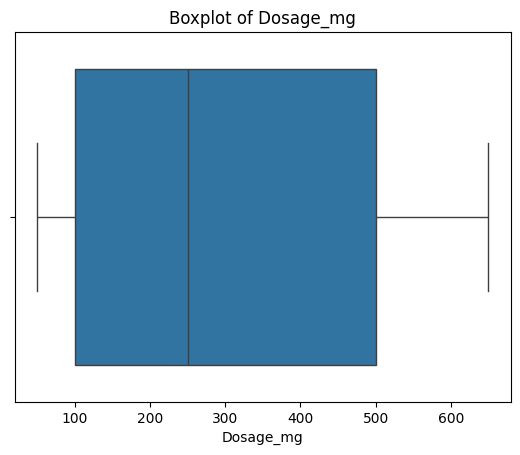

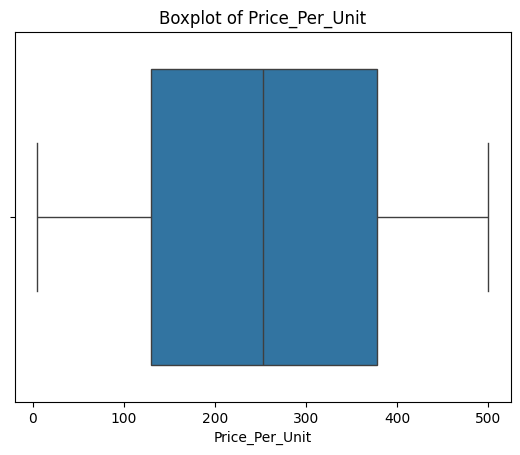

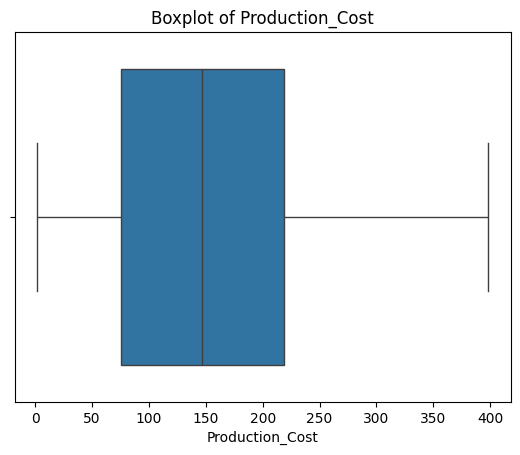

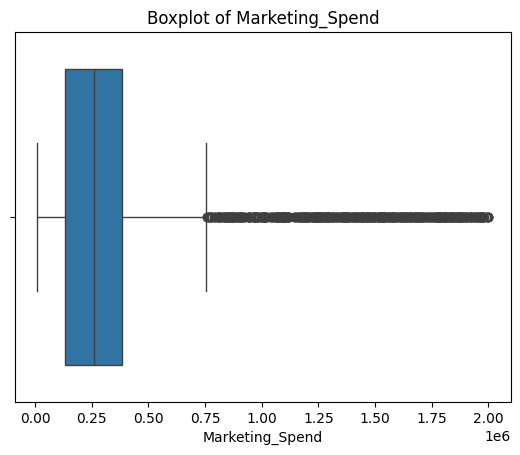

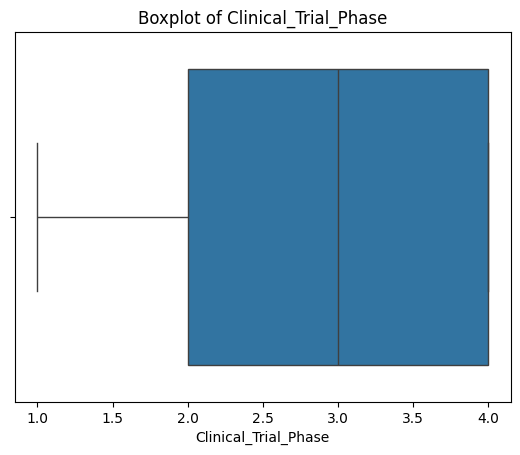

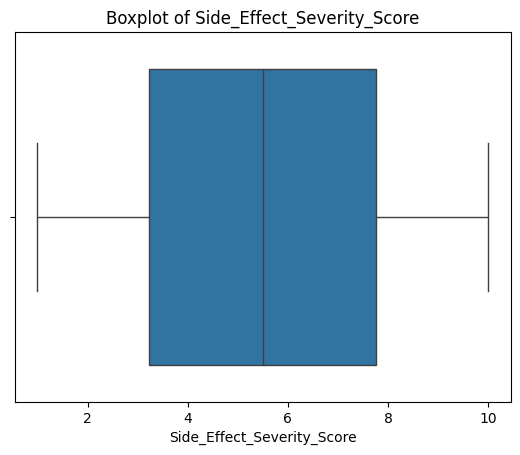

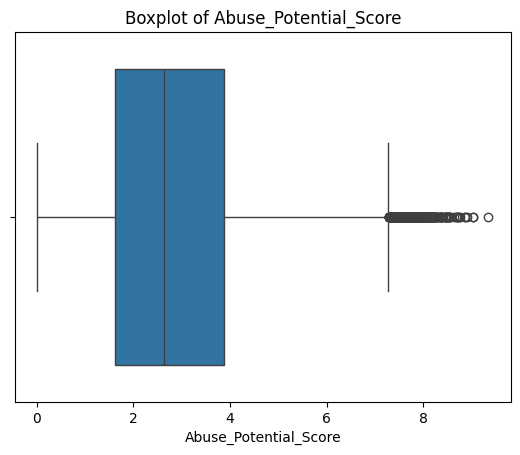

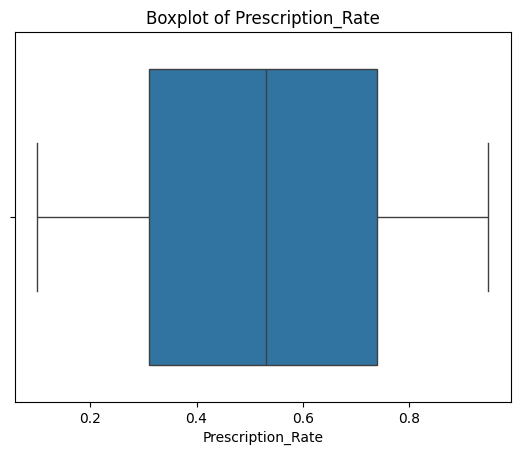

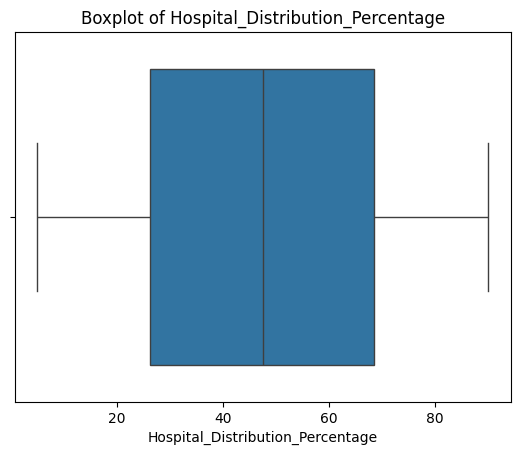

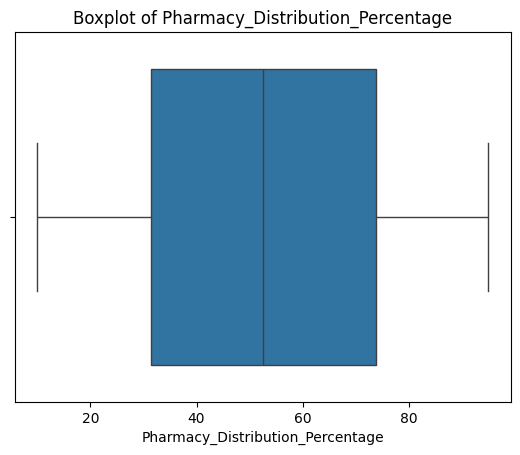

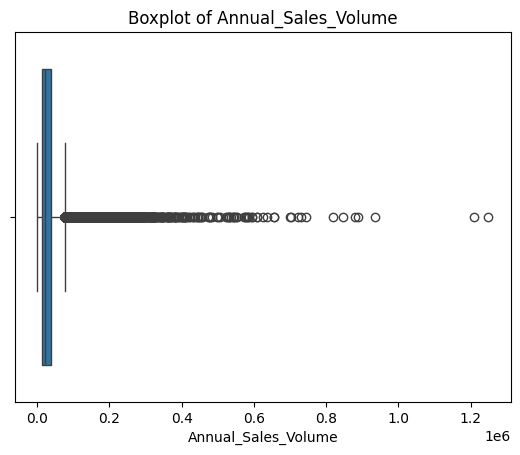

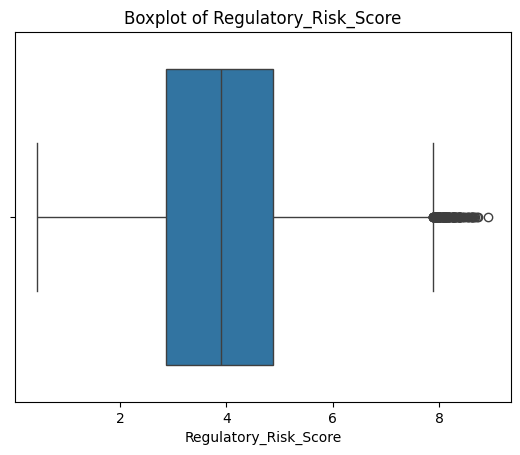

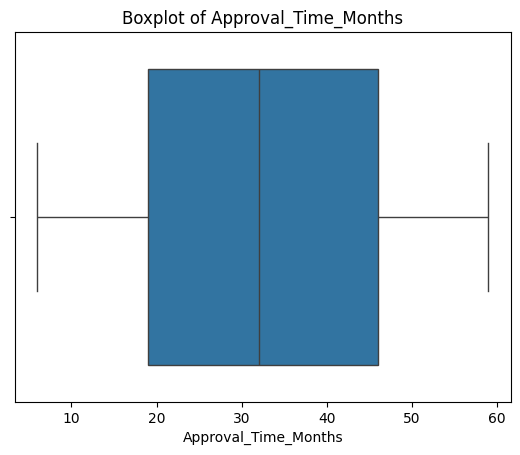

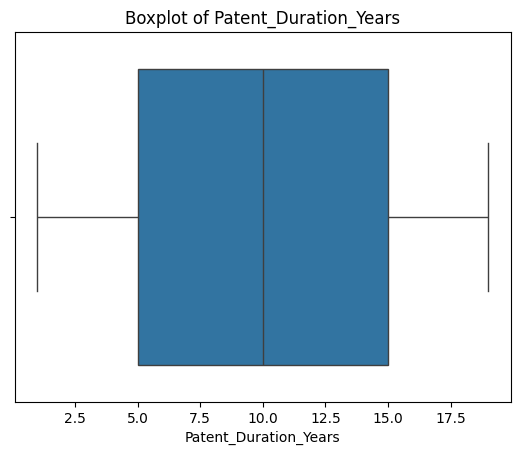

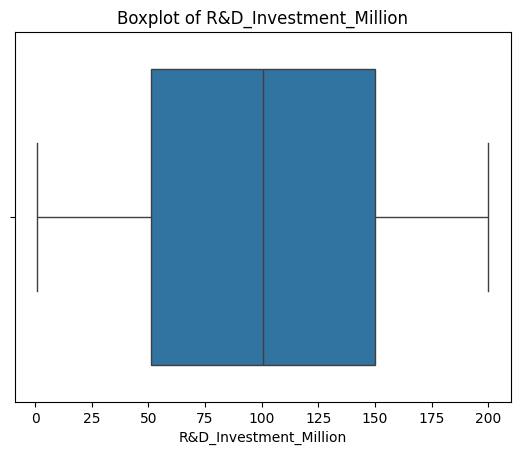

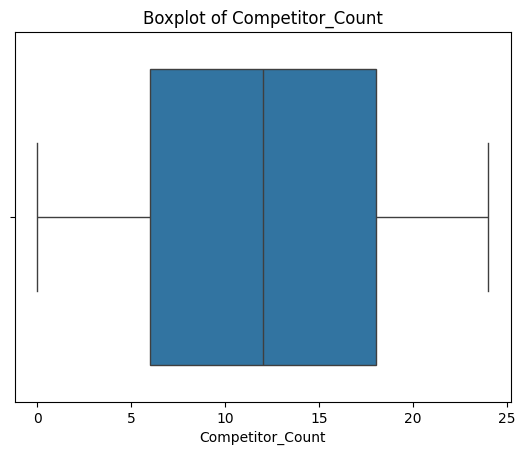

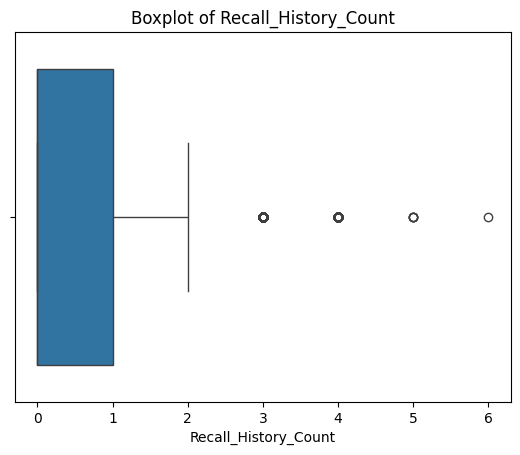

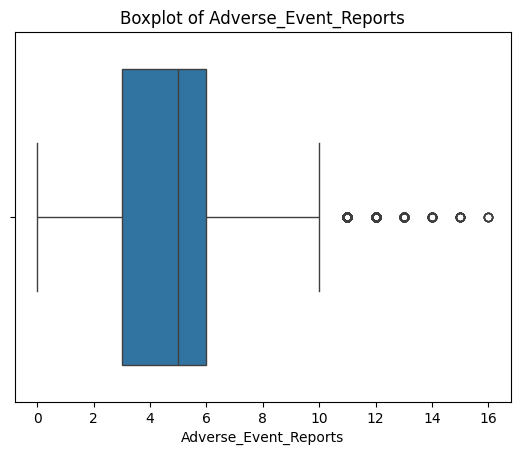

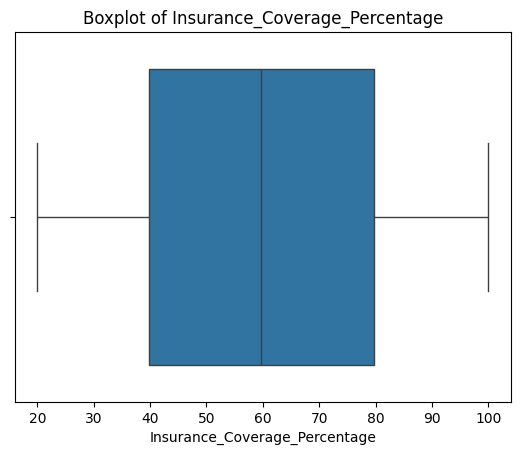

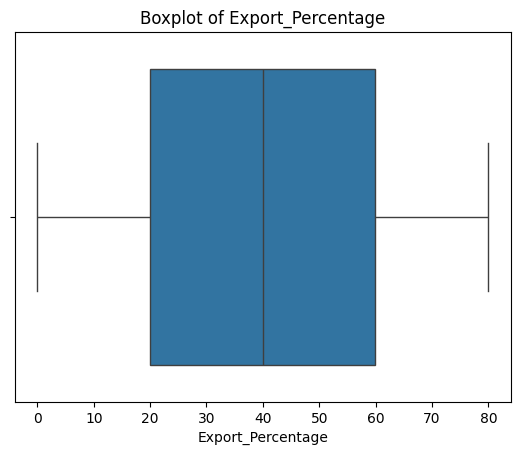

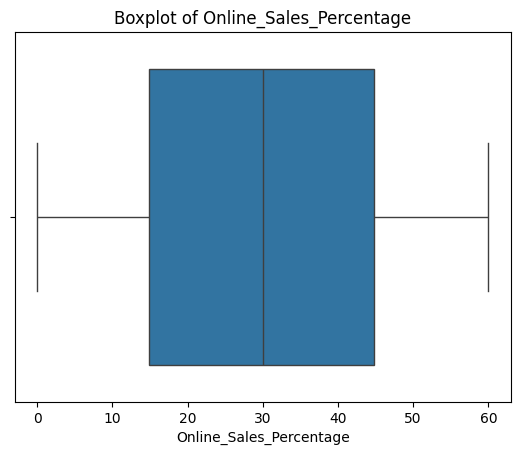

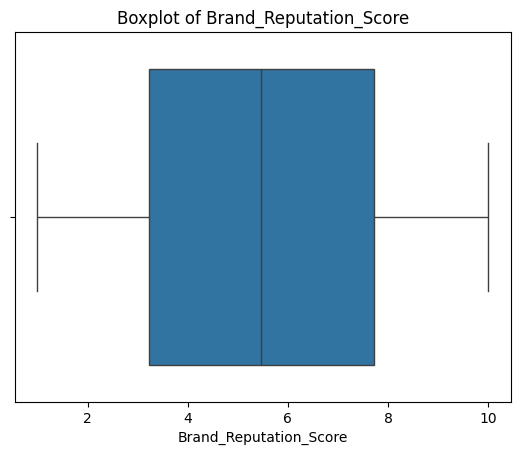

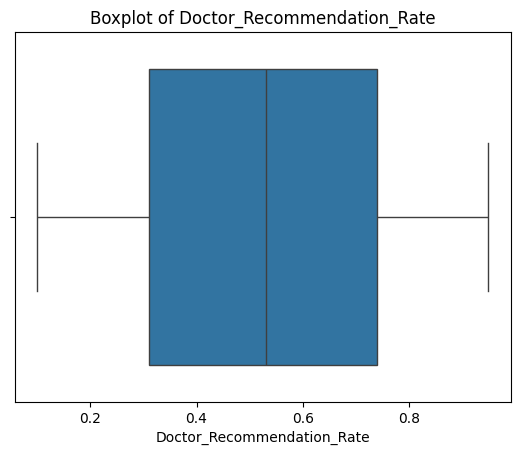

In [11]:
for col in numeric_feature:
    plt.figure()
    sns.boxplot(x=dataset[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [12]:
#creating numerical pipeline 
#SimpleImputer used to treat missing values
#Winsorizer used to treat outliers
#MinMaxScaler used tom scale value between 0 to 1 range
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(capping_method='iqr', tail='both', fold=1.5)),
    ('scaler', MinMaxScaler())
])

#creating catagorical pipeline
#OneHotEncoder used to convert catagorical classes into binary class or numericals
catagorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown="ignore"))
])

In [13]:
#allow you to preprocess numrical and catagrical features seperately within a single pipeline
preprocess_pipeline = ColumnTransformer([
    ('numerical', numeric_pipeline, numeric_feature),
    ('catagorical', catagorical_pipeline, catagorical_feature)
])

In [14]:
#preprocess pipeline learns the required parameters
clean = preprocess_pipeline.fit(x)

In [15]:
#transforming data using already fitted pipeline and stores process result as dataframe
Clean_data = pd.DataFrame(clean.transform(x))

In [16]:
Clean_data.head()

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0.333333,0.725745,0.616880,0.200293,0.666667,0.362222,0.345017,0.752941,0.622706,0.377294,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.750000,0.217885,0.179572,0.336568,0.333333,0.791111,0.246048,0.447059,0.505882,0.494118,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.250000,0.388370,0.248978,0.130030,0.666667,0.064444,0.200687,0.976471,0.582118,0.417882,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,0.750000,0.744595,0.662990,0.297228,1.000000,0.080000,0.219931,0.517647,0.496471,0.503529,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.750000,0.704833,0.694614,0.415553,0.333333,0.960000,0.060481,0.470588,0.964235,0.035765,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [17]:
#save trained preprocessing pipeline int file for reuse
joblib.dump(clean, 'preprocess_pipeline.pkl')

['preprocess_pipeline.pkl']

In [18]:
#load pipeline for reuse in testing
preprocess_pipeline = joblib.load('preprocess_pipeline.pkl')

In [19]:
print(Clean_data.head())

         0         1         2         3         4         5         6   \
0  0.333333  0.725745  0.616880  0.200293  0.666667  0.362222  0.345017   
1  0.750000  0.217885  0.179572  0.336568  0.333333  0.791111  0.246048   
2  0.250000  0.388370  0.248978  0.130030  0.666667  0.064444  0.200687   
3  0.750000  0.744595  0.662990  0.297228  1.000000  0.080000  0.219931   
4  0.750000  0.704833  0.694614  0.415553  0.333333  0.960000  0.060481   

         7         8         9   ...   26   27   28   29   30   31   32   33  \
0  0.752941  0.622706  0.377294  ...  1.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0   
1  0.447059  0.505882  0.494118  ...  0.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0   
2  0.976471  0.582118  0.417882  ...  0.0  0.0  1.0  0.0  1.0  0.0  0.0  1.0   
3  0.517647  0.496471  0.503529  ...  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0   
4  0.470588  0.964235  0.035765  ...  0.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0   

    34   35  
0  0.0  0.0  
1  1.0  0.0  
2  1.0  0.0  
3  1.0  0.0 

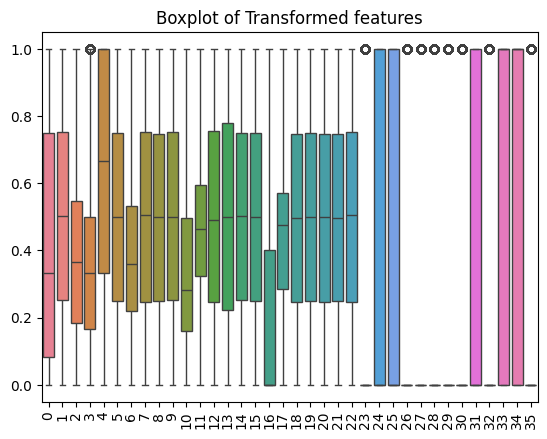

In [20]:
plt.figure()
sns.boxplot(data = Clean_data)
plt.xticks(rotation=90)
plt.title("Boxplot of Transformed features")
plt.show()